# Experimenting with TempestExtremes output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

In [2]:
def parse_nodefile(filepath):
    tracks = []
    current_track = []
    
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) == 0:
                continue
            if parts[0] == 'start':
                if current_track:
                    tracks.append(pd.DataFrame(current_track))
                current_track = []
            else:
                current_track.append({
                    'lon': float(parts[2]),
                    'lat': float(parts[3]),
                    'msl': float(parts[4]) / 100.0,  # convert Pa to hPa
                    'z': float(parts[5]),
                    'year': int(parts[6]),
                    'month': int(parts[7]),
                    'day': int(parts[8]),
                    'hour': int(parts[9]),
                })
        if current_track:
            tracks.append(pd.DataFrame(current_track))
    
    return tracks

In [ ]:
tracks_2020_hourly = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020.txt')
tracks_2020_6hourly = parse_nodefile('/data1/lepique/era5_test/tracks_2020_1.txt')
tracks_2020_hourly_2 = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020_2.txt')
tracks_2020_hourly_3 = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020_3.txt')
tracks_2020_hourly_4 = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020_4.txt')
tracks_2020_hourly_5 = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020_5.txt')
tracks_2020_hourly_6 = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020_6.txt')
tracks_2020_hourly_7 = parse_nodefile('/data1/lepique/era5_test/tracks_hourly_2020_7.txt')
new_tracks = parse_nodefile('/data1/lepique/era5_test/track_sensitivities/tracks_hourly_2020_9.txt')


In [3]:
full_tracks = parse_nodefile('/data1/lepique/TempestExtremes/tracks/tracks_hourly_1996_2025.txt')
#gore_tracks = parse_nodefile('/data1/lepique/era5_test/trajsens2.ERA5.gore.txt')
kiefer_tracks = parse_nodefile('/data1/lepique/era5_test/trajsens2.ERA5.hourly_kiefer.txt')

In [7]:
# US domain bounds (as in Kiefer et al. 2026)
# 135W-55W = 225E-305E in 0-360 convention
LON_MIN = 225.0
LON_MAX = 305.0
LAT_MIN = 20.0
LAT_MAX = 70.0

In [8]:
def track_passes_over_us(track_df):
    """ Return True if any point in the track is within the US domain."""
    in_domain = (
        (track_df['lon'] >= LON_MIN) & 
        (track_df['lon'] <= LON_MAX) & 
        (track_df['lat'] >= LAT_MIN) & 
        (track_df['lat'] <= LAT_MAX)
    )
    return in_domain.any()

In [9]:
# us_tracks_hourly = [t for t in tracks_2020_hourly if track_passes_over_us(t)]
# us_tracks_6hourly = [t for t in tracks_2020_6hourly if track_passes_over_us(t)]
# us_tracks_hourly_2 = [t for t in tracks_2020_hourly_2 if track_passes_over_us(t)]
# us_tracks_hourly_3 = [t for t in tracks_2020_hourly_3 if track_passes_over_us(t)]
# us_tracks_hourly_4 = [t for t in tracks_2020_hourly_4 if track_passes_over_us(t)]
# us_tracks_hourly_5 = [t for t in tracks_2020_hourly_5 if track_passes_over_us(t)]
# us_tracks_hourly_6 = [t for t in tracks_2020_hourly_6 if track_passes_over_us(t)]
# us_tracks_hourly_7 = [t for t in tracks_2020_hourly_7 if track_passes_over_us(t)]
# us_tracks_hourly_9 = [t for t in new_tracks if track_passes_over_us(t)]



In [10]:
#us_gore_tracks = [t for t in gore_tracks if track_passes_over_us(t)]
us_kiefer_tracks = [t for t in kiefer_tracks if track_passes_over_us(t)]  
us_full_tracks = [t for t in full_tracks if track_passes_over_us(t)]

In [11]:
# gore_single_year = [
#     t for t in us_gore_tracks
#     if (
#         t['year'] == 2019
#     ).any()
    
#]
kiefer_single_year = [
    t for t in us_kiefer_tracks
    if (
        t['year'] == 2020
    ).any()
]
#print(len(gore_single_year))
print(len(kiefer_single_year))
#print(len(us_tracks))

205


In [11]:
# winter_tracks_hourly = [t for t in us_tracks_hourly if t['month'].isin([1,2,3]).any()]
# winter_tracks_6hourly = [t for t in us_tracks_6hourly if t['month'].isin([1,2,3]).any()]
# winter_tracks_hourly_2 = [t for t in us_tracks_hourly_2 if t['month'].isin([1,2,3]).any()]
# winter_tracks_hourly_3 = [t for t in us_tracks_hourly_3 if t['month'].isin([1,2,3]).any()]
# winter_tracks_hourly_4 = [t for t in us_tracks_hourly_4 if t['month'].isin([1,2,3]).any()]
# winter_tracks_hourly_5 = [t for t in us_tracks_hourly_5 if t['month'].isin([1,2,3]).any()]
# winter_tracks_hourly_6 = [t for t in us_tracks_hourly_6 if t['month'].isin([1,2,3]).any()]
# winter_tracks_hourly_7 = [t for t in us_tracks_hourly_7 if t['month'].isin([1,2,3]).any()]


# winter_tracks = [
#     t for t in us_tracks
#     if (
#         (t['month'] == 2) & 
#         (t['day'].isin([5,6,7,8]))
#     ).any()
# ]
#winter_gore_tracks = [t for t in gore_single_year if t['month'].isin([12,1,2,3]).any()]
winter_kiefer_tracks = [t for t in us_kiefer_tracks if t['month'].isin([1,2,3,12]).any()]
winter_tracks_hourly = [t for t in us_full_tracks if t['month'].isin([1,2,3,12]).any()]


In [12]:
# print("Range 1.5:",len(winter_tracks_hourly))
# print("Range 2.0:",len(winter_tracks_hourly_2))
# print("Range 3.0:",len(winter_tracks_hourly_3))
# print("Range 4.0:",len(winter_tracks_hourly_4))
# print("Range 6.0:",len(winter_tracks_hourly_5))
# print("Range 9.01:",len(winter_tracks_hourly_6))
# print("Range 6.0 AND CONUS Threshold:",len(winter_tracks_hourly_7))
# print("Range 5.0", len(winter_tracks_hourly_8))



# print("6-hourly resolution (range 9.01):",len(winter_tracks_6hourly))
print("Kiefer et al.:",len(winter_kiefer_tracks))
print("My new tracks:", len(winter_tracks_hourly))

Kiefer et al.: 3151
My new tracks: 2232


In [13]:
winter_kiefer_tracks


[       lon    lat       msl    z  year  month  day  hour
 0   253.25  44.50  1009.862  0.0  1980      1    1     1
 1   253.25  44.50  1009.083  0.0  1980      1    1     2
 2   253.25  44.50  1009.243  0.0  1980      1    1     3
 3   253.25  44.50  1009.673  0.0  1980      1    1     4
 4   253.25  44.25  1009.686  0.0  1980      1    1     5
 5   253.25  44.25  1009.220  0.0  1980      1    1     6
 6   253.25  44.25  1008.872  0.0  1980      1    1     7
 7   253.25  44.25  1008.525  0.0  1980      1    1     8
 8   253.25  44.00  1009.037  0.0  1980      1    1     9
 9   253.25  43.75  1009.327  0.0  1980      1    1    10
 10  255.50  39.25  1008.522  0.0  1980      1    1    11
 11  255.50  39.25  1008.576  0.0  1980      1    1    12
 12  255.50  39.00  1008.153  0.0  1980      1    1    13
 13  255.50  39.00  1008.592  0.0  1980      1    1    14
 14  256.00  37.00  1008.377  0.0  1980      1    1    15
 15  256.00  37.00  1009.298  0.0  1980      1    1    16
 16  256.00  3

In [14]:
winter_tracks_hourly

[        lon    lat        msl            z  year  month  day  hour
 0    206.75  47.50   994.8150    -0.245519  1996      1    1     0
 1    207.25  48.00   995.0500     0.673819  1996      1    1     1
 2    208.00  48.50   995.8494    -0.646633  1996      1    1     2
 3    208.75  52.25   996.0956     0.134485  1996      1    1     3
 4    209.75  53.00   995.9644    -0.710366  1996      1    1     4
 ..      ...    ...        ...          ...   ...    ...  ...   ...
 112  253.75  37.75  1008.3800  2541.630000  1996      1    5    23
 113  254.00  37.75  1009.3090  2255.822000  1996      1    6     0
 114  254.00  37.75  1010.2990  2255.822000  1996      1    6     1
 115  254.00  37.75  1011.1360  2255.822000  1996      1    6     2
 116  254.00  37.75  1013.1090  2255.822000  1996      1    6     3
 
 [117 rows x 8 columns],
         lon    lat       msl           z  year  month  day  hour
 0    259.50  33.75  994.8975  626.466100  1996      1    1     0
 1    259.50  33.50  995.

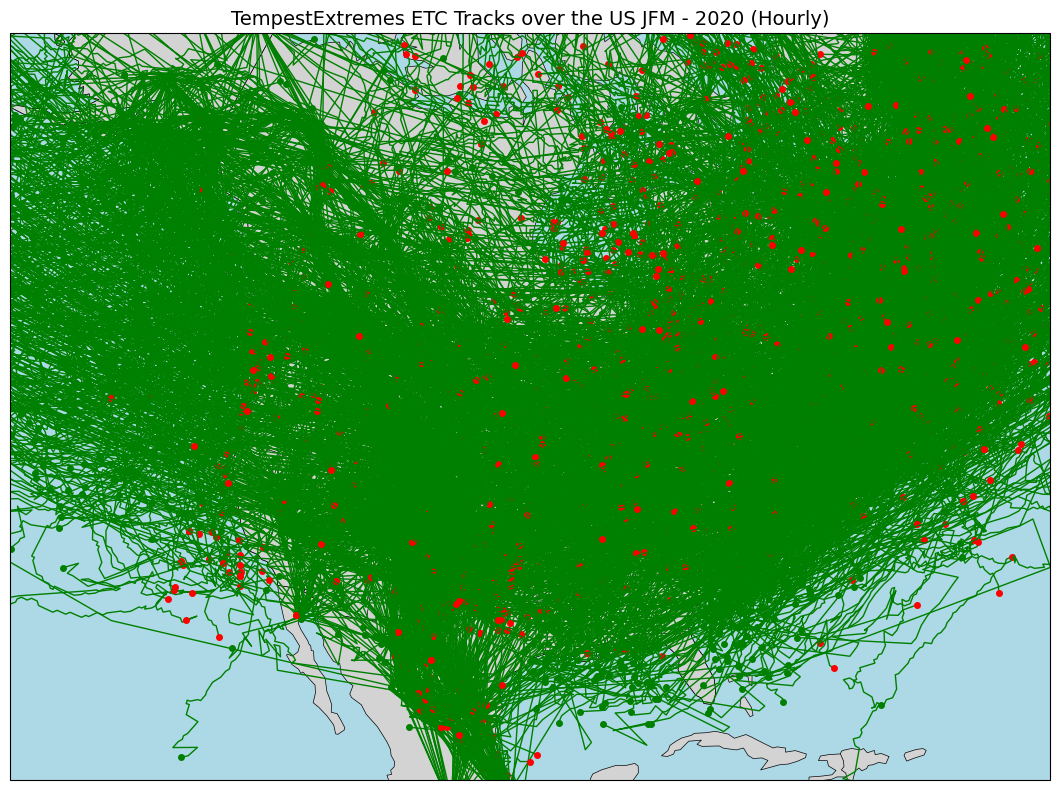

In [16]:
fig, ax = plt.subplots(
    figsize=(12,8),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-95)}
)

ax.set_extent([-135,-55, 20, 70], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)  # US state boundaries
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')


#n = len(us_tracks)
#cmap = mpl.colormaps.get_cmap('tab20')
## loop through each US track and plot it
for i, track in enumerate(winter_tracks_hourly):
    ## convert longitudes from 0-360 to -180-180 convention for cartopy
    lons = track['lon'].values
    lons[lons > 180] -=360
    lats = track['lat'].values

    #color = cmap(i)
    ## plot the track line
    ax.plot(lons,lats,
            transform=ccrs.PlateCarree(),
            color='green', linewidth=1)

    ## Plot dot at start and end of each track
    ax.plot(lons[0], lats[0],
            transform = ccrs.PlateCarree(),
            marker='o', color='green', markersize=4)
    ax.plot(lons[-1], lats[-1],
            transform=ccrs.PlateCarree(),
            marker='o', color='red', markersize=4)


ax.set_title('TempestExtremes ETC Tracks over the US JFM - 2020 (Hourly)', fontsize=14)
plt.tight_layout()
#plt.savefig('TE_tracks_kiefer.png', dpi=150)
#print(len(winter_tracks))
#print(len(winter_gore_tracks))
#print(len(winter_kiefer_tracks))
plt.show()

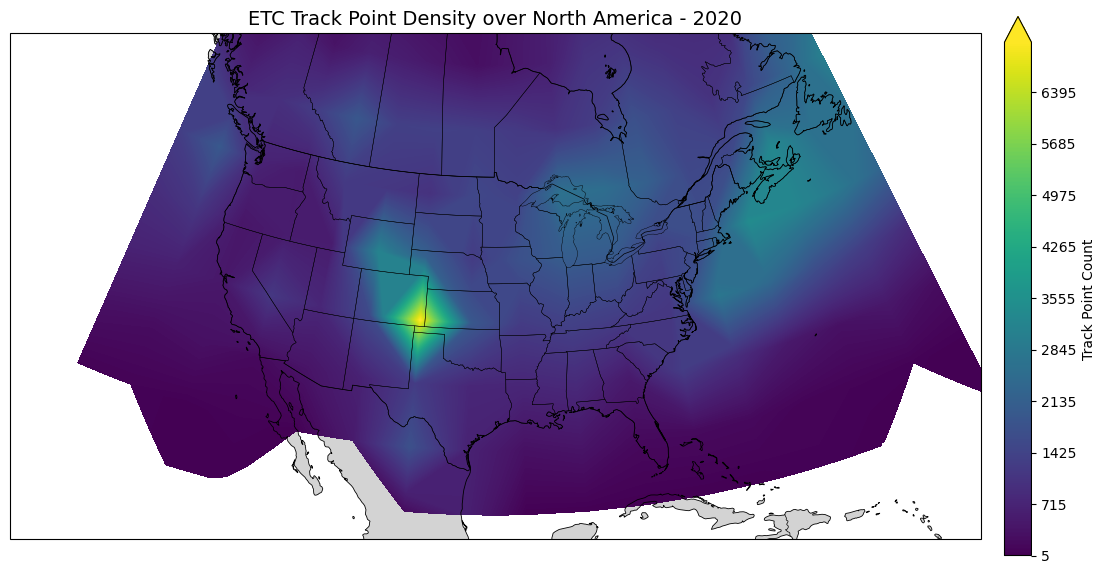

In [17]:
### Density map:

all_lons, all_lats = [],[]
for track in winter_tracks_hourly:
    lons = track['lon'].values.copy()
    lons[lons>180] -=360
    all_lons.extend(lons)
    all_lats.extend(track['lat'].values)

all_lons = np.array(all_lons)
all_lats = np.array(all_lats)

## bin track points onto a regular grid
res = 5.0 ## degrees
lon_bins=np.arange(-135,-54+res,res)
lat_bins = np.arange(20,71+res,res)

counts, lon_edges, lat_edges = np.histogram2d(all_lons, all_lats, bins=[lon_bins, lat_bins])

## grid centers for plotting
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

## mask zeroes so they show as background
counts_masked = np.ma.masked_where(counts == 0, counts)

fig, ax = plt.subplots(
    figsize=(12,8),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-95)}
)
ax.set_extent([-135,-55,20,55], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)
ax.add_feature(cfeature.STATES, linewidth=0.3, zorder=2)

cf = ax.contourf(lon_grid, lat_grid, counts_masked.T,
                 levels = np.arange(5,counts.max()+1, 5),
                 cmap='viridis',
                 transform=ccrs.PlateCarree(),
                 #vmin=0, vmax=65,
                 zorder=1,
                 extend='max'
)
plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, shrink=0.7, label='Track Point Count')
ax.set_title('ETC Track Point Density over North America - 2020', fontsize=14)
plt.tight_layout()
#plt.savefig('TE_track_density_test.png', dpi=150)
plt.show()
plt.close()

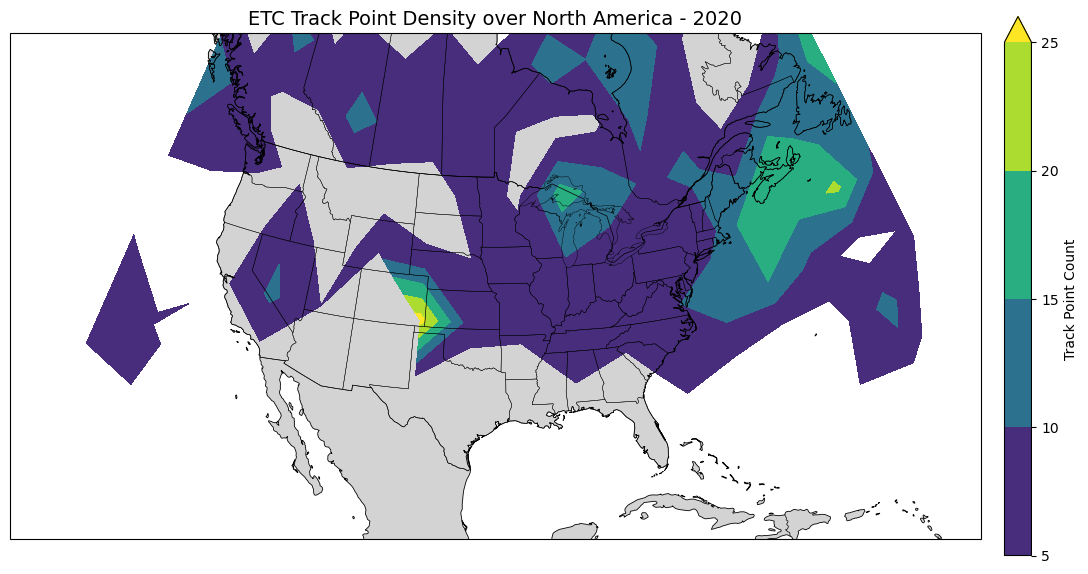

In [ ]:
## plotting ETC tracks during DJFM:
all_lons, all_lats = [],[]
for track in us_tracks:
    if track['month'].isin([12,1,2,3]).any():
        lons = track['lon'].values.copy()
        lons[lons>180] -=360
        all_lons.extend(lons)
        all_lats.extend(track['lat'].values)
all_lons = np.array(all_lons)
all_lats = np.array(all_lats)

## bin track points onto a regular grid
res = 5.0 ## degrees
lon_bins=np.arange(-135,-54+res,res)
lat_bins = np.arange(20,71+res,res)

counts, lon_edges, lat_edges = np.histogram2d(all_lons, all_lats, bins=[lon_bins, lat_bins])

## grid centers for plotting
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

counts_masked = np.ma.masked_where(counts == 0, counts)

fig, ax = plt.subplots(
    figsize=(12,8),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-95)}
)
ax.set_extent([-135,-55,20,55], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)
ax.add_feature(cfeature.STATES, linewidth=0.3, zorder=2)

cf = ax.contourf(lon_grid, lat_grid, counts_masked.T,
                 levels = np.arange(5,counts.max()+1, 5),
                 cmap='viridis',
                 transform=ccrs.PlateCarree(),
                 #vmin=0, vmax=65,
                 zorder=1,
                 extend='max'
)
plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, shrink=0.7, label='Track Point Count')
ax.set_title('ETC Track Point Density over North America - 2020', fontsize=14)
plt.tight_layout()
#plt.savefig('TE_track_density_test.png', dpi=150)
plt.show()
plt.close()

In [ ]:
### Plotting ERA5 MSL to verify that the tracks are capturing the expected low pressure centers during the Feb 2020 storm cluster:
data = xr.open_dataset('/data1/lepique/era5_test/era5_msl_202002.nc')

In [ ]:
msl = data['msl'] / 100.0

In [ ]:

msl = msl.sel(
    valid_time='2020-02-07T12:00:00.000000000',
    latitude=slice(70,20),
    longitude=slice(225,305)
    )

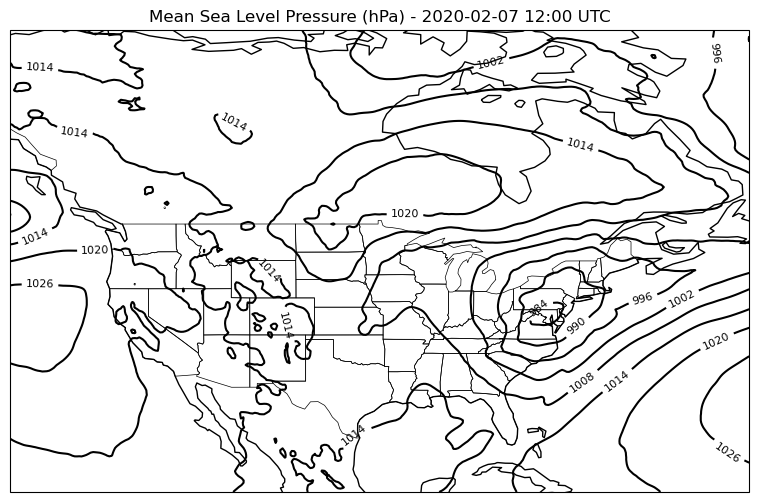

In [ ]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())


cs = ax.contour(
    msl.longitude,
    msl.latitude,
    msl,
    colors='black',
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d')


ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)

#plt.colorbar(cf, label="Geopotential height (m)")
plt.title("Mean Sea Level Pressure (hPa) - 2020-02-07 12:00 UTC")
plt.savefig('era5_test.png', dpi=150)
plt.show()

### Checking the cyclone candidates to see if the storm is present:

In [5]:
def parse_candidates(filepath):
    records=[]
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) == 0:
                continue

            ## header line - extract date info
            if len(parts) == 5:
                current_year = int(parts[0])
                current_month = int(parts[1])
                current_day = int(parts[2])
                n_candidates = int(parts[3]) ## optional
                current_hour = int(parts[4])
            elif len(parts) == 6:
                records.append({
                    'lon': float(parts[2]),
                    'lat': float(parts[3]),
                    'msl': float(parts[4]) / 100.0,  # convert Pa to hPa
                    'z': float(parts[5]),
                    'year': current_year,
                    'month': current_month,
                    'day': current_day,
                    'hour': current_hour,
                })
    return pd.DataFrame(records)

In [6]:
candidates = parse_candidates('/data1/lepique/era5_test/candidates_2020_2.txt')

In [ ]:
len(candidates)

47086

In [ ]:
mask = (
    (candidates['month']==2) &
    (candidates['day'] == 7) &
    (candidates['lon'] >=260) &
    (candidates['lon'] <= 290) &
    (candidates['lat'] >= 35) &   
    (candidates['lat'] <= 45)
)

In [ ]:
print(candidates[mask])

         lon    lat       msl         z  year  month  day  hour
4394  280.50  39.75  991.5319  618.9026  2020      2    7     0
4426  278.75  36.75  988.0456  896.5427  2020      2    7     6
4453  282.75  39.50  981.9675  181.9216  2020      2    7    12
4485  287.25  41.75  972.7256  109.7799  2020      2    7    18


## New Parse_nodfile code to build a single dataframe with track IDs

In [20]:
def new_parse_nodefile(filepath):
    """ 
    Parse a TempestExtremes StitchNodes nodefile into a single dataframe with one row per ETC center detection, tagged with a unique track_id
    """
    records=[]
    track_id = 0 # 1 is the first "start" line

    with open(filepath,'r') as f:
        for line in f:
            parts = line.split()
            if len(parts)==0:
                continue
            if parts[0] == 'start':
                ## new trajectory tarting; increment track_id
                track_id += 1
            else:
                ## data line: parse fields and append to records list tagged with current track_id
                records.append({
                    'track_id': track_id,
                    'lon': float(parts[2]),
                    'lat': float(parts[3]),
                    'msl': float(parts[4]) / 100.0,  # convert Pa to hPa
                    'z': float(parts[5]),
                    'year': int(parts[6]),
                    'month': int(parts[7]),
                    'day': int(parts[8]),
                    'hour': int(parts[9]),
                })
    df = pd.DataFrame(records)
    df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])
    return df

In [22]:
new_tracks = new_parse_nodefile('/data1/lepique/era5_test/track_sensitivities/tracks_hourly_2020_9.txt')

In [23]:
new_tracks


,track_id,lon,lat,msl,z,year,month,day,hour,datetime
0,1,293.00,44.50,991.6106,32.76416,2020,1,1,0,2020-01-01 00:00:00
1,1,293.25,44.75,991.2206,68.09619,2020,1,1,1,2020-01-01 01:00:00
2,1,293.50,45.00,991.4325,172.72510,2020,1,1,2,2020-01-01 02:00:00
3,1,293.75,45.25,991.0762,665.60010,2020,1,1,3,2020-01-01 03:00:00
4,1,294.00,45.50,990.5550,779.02980,2020,1,1,4,2020-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...
28523,230,299.25,51.00,996.6162,2793.20900,2020,12,31,19,2020-12-31 19:00:00
28524,230,300.25,51.00,996.6594,2014.13100,2020,12,31,20,2020-12-31 20:00:00
28525,230,300.75,51.25,996.1962,1856.81100,2020,12,31,21,2020-12-31 21:00:00
28526,230,301.25,51.50,995.5794,1734.69000,2020,12,31,22,2020-12-31 22:00:00


In [24]:
def filter_tracks(all_tracks):
    """
    Return a dataframe containing only cyclone tracks
    that pass through the CONUS domain at least once.
    """

    valid_track_ids = []

    for track_id, track_df in all_tracks.groupby('track_id'):

        in_domain = (
            (track_df['lon'] >= LON_MIN) &
            (track_df['lon'] <= LON_MAX) &
            (track_df['lat'] >= LAT_MIN) &
            (track_df['lat'] <= LAT_MAX)
        )

        if in_domain.any():
            valid_track_ids.append(track_id)

    us_tracks = all_tracks[
        all_tracks['track_id'].isin(valid_track_ids)
    ]

    us_tracks_djfm = us_tracks[
        (us_tracks['month'].isin([1,2,3]))
    ]

    return us_tracks_djfm

In [25]:
new_us_tracks = filter_tracks(new_tracks)

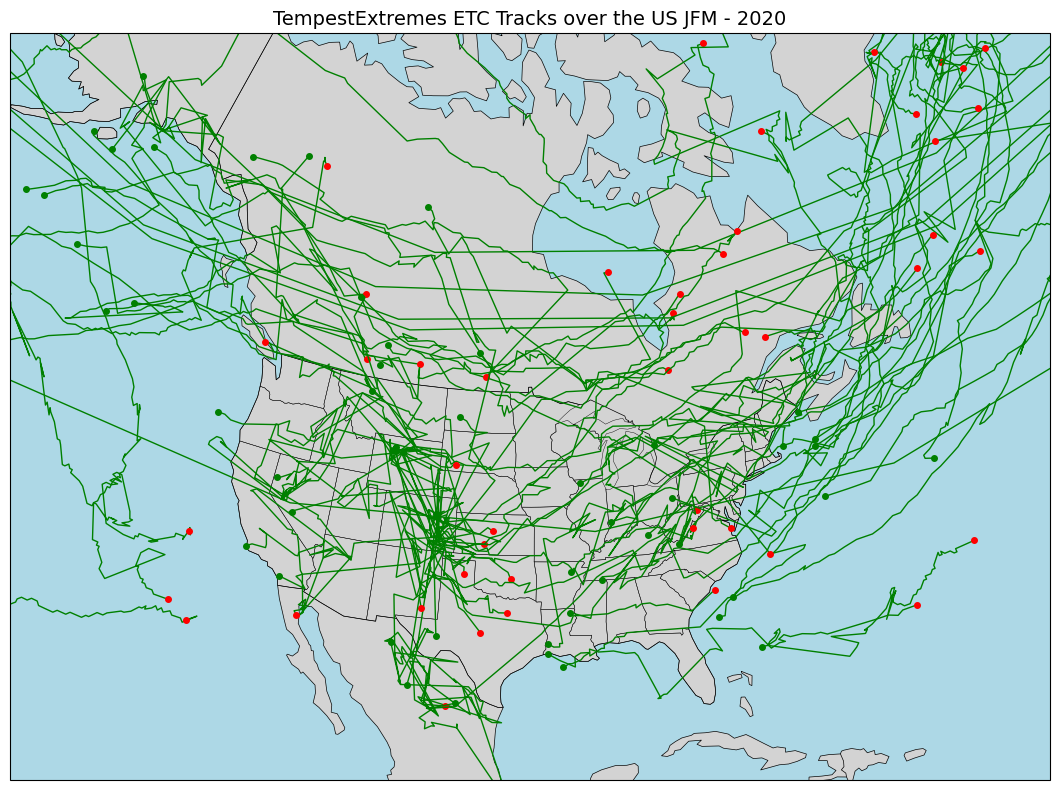

In [26]:
fig, ax = plt.subplots(
    figsize=(12,8),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-95)}
)

ax.set_extent([-135,-55, 20, 70], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)  # US state boundaries
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')


#n = len(us_tracks)
#cmap = mpl.colormaps.get_cmap('tab20')
## loop through each US track and plot it
for track_id, track in new_us_tracks.groupby('track_id'):
    ## convert longitudes from 0-360 to -180-180 convention for cartopy
    lons = track['lon'].values.copy()
    lons[lons > 180] -=360
    lats = track['lat'].values

    #color = cmap(i)
    ## plot the track line
    ax.plot(lons,lats,
            transform=ccrs.PlateCarree(),
            color='green', linewidth=1)

    ## Plot dot at start and end of each track
    ax.plot(lons[0], lats[0],
            transform = ccrs.PlateCarree(),
            marker='o', color='green', markersize=4)
    ax.plot(lons[-1], lats[-1],
            transform=ccrs.PlateCarree(),
            marker='o', color='red', markersize=4)


ax.set_title('TempestExtremes ETC Tracks over the US JFM - 2020', fontsize=14)
plt.tight_layout()
# plt.savefig('TE_tracks_test.png', dpi=150)

In [8]:
new_tracks.groupby('track_id').size()

track_id
1       13
2       50
3       12
4       11
5        6
        ..
1468     8
1469     7
1470     9
1471     5
1472     5
Length: 1472, dtype: int64